Shear Matrix
========================

Credit: Bekah Polen (Duke)

$A = \begin{pmatrix} 1-\kappa-\gamma_{1}, -\gamma_{2} \\ -\gamma_{2}, 1-\kappa+\gamma_{1} \end{pmatrix}$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Ellipse

2D Heat Maps of Shear and Convergence
-------------------------------------

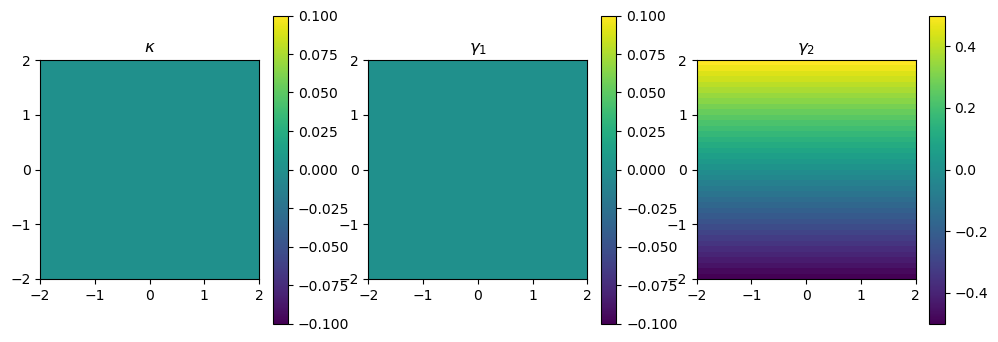

In [2]:
# Example grid
theta_x, theta_y = np.meshgrid(np.linspace(-2, 2, 40), np.linspace(-2, 2, 40))

# Define and toggle kappa, gamma1, and gamma2
# kappa = 0.05 * np.exp(-0.5*(theta_x**2 + theta_y**2))
kappa = 0.00 * np.exp(-0.5*(theta_x**2 + theta_y**2))
# gamma1 = 0.4 * theta_x
gamma1 = 0.0 * theta_x
gamma2 = 0.25 * theta_y
# gamma2 = 0.0 * theta_y

# Plot heat maps
fig, axs = plt.subplots(1, 3, figsize=(12,4))
for ax, data, title in zip(axs, [kappa, gamma1, gamma2],
                           [r'$\kappa$', r'$\gamma_1$', r'$\gamma_2$']):
    im = ax.imshow(data, origin='lower', extent=(-2,2,-2,2))
    fig.colorbar(im, ax=ax)
    ax.set_title(title)
plt.show()

Visualization of the Amplification Matrix
-----------------------------------------

Visualizing the arbitrary field generated above.

In [3]:
# Exercise: Fill out the A matrix
def calculate_amplification_matrix(gamma1, gamma2, kappa):
    A = (1-kappa)*np.array([[1-gamma1, -gamma2],[-gamma2, 1+gamma1]])
    return A


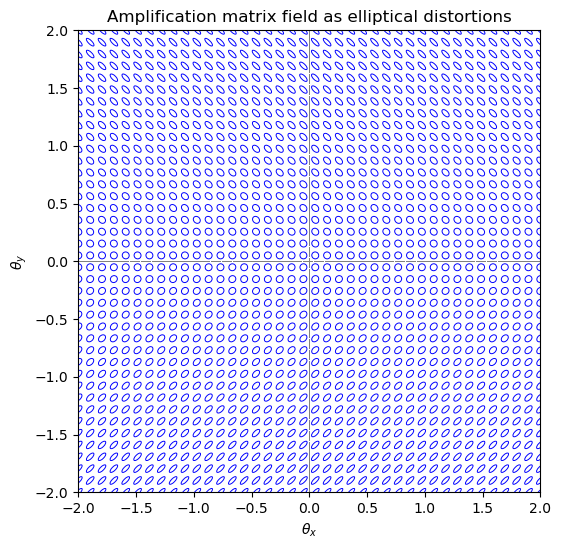

In [4]:
fig, ax = plt.subplots(figsize=(6,6))
for i in range(theta_x.shape[0]):
    for j in range(theta_x.shape[1]):
        A = calculate_amplification_matrix(gamma1[i,j], gamma2[i,j], kappa[i, j])
        # Compute eigenvalues/vectors to represent local stretch
        vals, vecs = np.linalg.eigh(A @ A.T)
        width, height = 0.06 * np.sqrt(vals)
        angle = np.degrees(np.arctan2(vecs[1,0], vecs[0,0]))

        e = Ellipse(
            xy=(theta_x[i,j], theta_y[i,j]),
            width=width,
            height=height,
            angle=angle,
            fill=False,
            edgecolor='blue',
            lw=0.7
        )
        ax.add_patch(e)
        ax.set_xlim(-2, 2)
        ax.set_ylim(-2, 2)
        ax.axhline(0, color='gray', lw=0.5, ls='--')
        ax.axvline(0, color='gray', lw=0.5, ls='--')

ax.set_aspect('equal')
ax.set_xlabel(r'$\theta_x$')
ax.set_ylabel(r'$\theta_y$')
ax.set_title("Amplification matrix field as elliptical distortions")
plt.show()

Just One Quadrant:
------------------

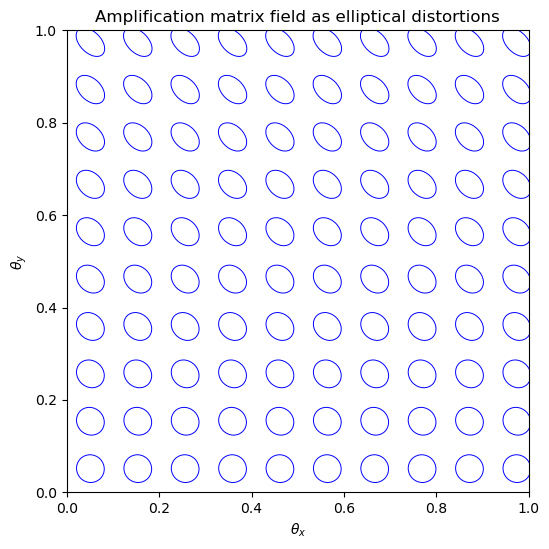

In [5]:
fig, ax = plt.subplots(figsize=(6,6))
for i in range(theta_x.shape[0]):
    for j in range(theta_x.shape[1]):
        A = calculate_amplification_matrix(gamma1[i, j], gamma2[i, j], kappa[i, j])
        # Compute eigenvalues/vectors to represent local stretch
        vals, vecs = np.linalg.eigh(A @ A.T)
        width, height = 0.06 * np.sqrt(vals)
        angle = np.degrees(np.arctan2(vecs[1,0], vecs[0,0]))

        e = Ellipse(
            xy=(theta_x[i,j], theta_y[i,j]),
            width=width,
            height=height,
            angle=angle,
            fill=False,
            edgecolor='blue',
            lw=0.7
        )
        ax.add_patch(e)

ax.set_aspect('equal')
ax.set_xlabel(r'$\theta_x$')
ax.set_ylabel(r'$\theta_y$')
ax.set_title("Amplification matrix field as elliptical distortions")
plt.show()

Realistic $\kappa$, $\gamma_{1}$, $\gamma_{2}$ for Isothermal Distribution:
----------------------------------------------------------------------------

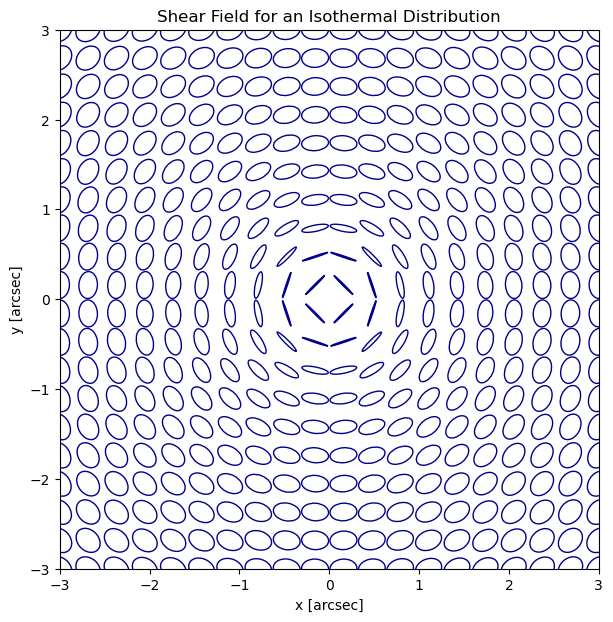

In [6]:
# Parameters
theta_E = 1.0          # Einstein radius in arcsec
npts = 20              # grid points in each direction
extent = 3.0            # arcsec range for plotting
ellipse_size = 0.3     # physical size of drawn ellipses

# Grid
x = np.linspace(-extent, extent, npts)
y = np.linspace(-extent, extent, npts)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)
phi = np.arctan2(Y, X)

# Distribution model
# This is a less arbitrary relationship between kappa and gamma
#epsilon = 1e-3
epsilon = 1e-5
kappa = theta_E / (2 * (R + epsilon))
gamma = kappa * np.exp(2j * phi + np.pi * 1j)  # tangential shear pattern

# Plot
fig, ax = plt.subplots(figsize=(7, 7))

for i in range(npts):
    for j in range(npts):
        g = gamma[j, i]
        amp = np.abs(g)
        # Cap shear to avoid extremely flattened ellipses near center
        amp = min(amp, 0.9)
        ang = 0.5 * np.angle(g) * 180/np.pi  # convert radians to degrees
        q = (1 - amp) / (1 + amp)            # axis ratio from shear magnitude

        e = Ellipse(
            (X[j, i], Y[j, i]),
            width=ellipse_size,
            height=ellipse_size * q,
            angle=ang,
            edgecolor='darkblue',
            facecolor='none',
            lw=1
        )
        ax.add_patch(e)
ax.set_aspect('equal')
ax.set_xlim(-extent, extent)
ax.set_ylim(-extent, extent)
ax.set_xlabel('x [arcsec]')
ax.set_ylabel('y [arcsec]')
ax.set_title('Shear Field for an Isothermal Distribution')
plt.show()

Shear Field as Ellipticities (Cosmic Shear)
-------------------------------------------

$e = \sqrt{\gamma_{1}^{2}+\gamma_{1}^{2}}$


$\phi = \frac{1}{2} \tan^{-1} (\frac{\gamma_{2}}{\gamma_{1}})$

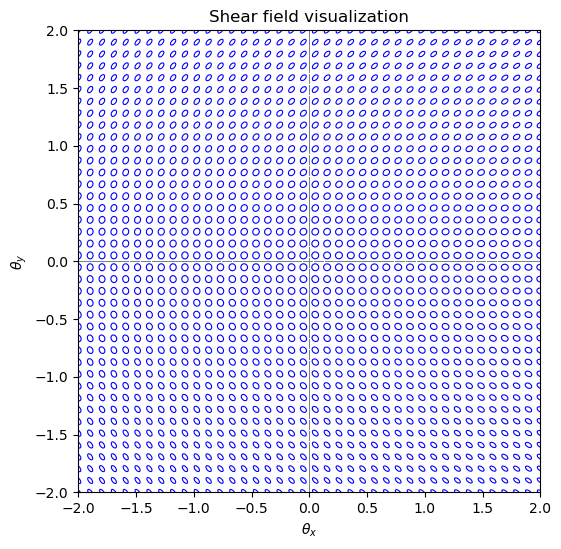

In [7]:
# Define a grid
theta_x, theta_y = np.meshgrid(np.linspace(-2, 2, 40), np.linspace(-2, 2, 40))

# Shear
gamma1 = 0.08 * theta_x
gamma2 = 0.25 * theta_y

fig, ax = plt.subplots(figsize=(6,6))
for i in range(theta_x.shape[0]):
    for j in range(theta_x.shape[1]):
        e = np.sqrt(gamma1[i,j]**2 + gamma2[i,j]**2)
        phi = 0.5 * np.arctan2(gamma2[i,j], gamma1[i,j])
        ellipse = Ellipse(
            xy=(theta_x[i,j], theta_y[i,j]),
            width=0.06,
            height=0.06*(1 - e),
            angle=np.degrees(phi),
            fill=False,
            edgecolor='blue',
            lw=0.8
        )
        ax.add_patch(ellipse)
        ax.set_xlim(-2, 2)
        ax.set_ylim(-2, 2)
        ax.axhline(0, color='gray', lw=0.5, ls='--')
        ax.axvline(0, color='gray', lw=0.5, ls='--')

ax.set_aspect('equal')
ax.set_xlabel(r'$\theta_x$')
ax.set_ylabel(r'$\theta_y$')
ax.set_title("Shear field visualization")
plt.show()

Ellipticity
-----------

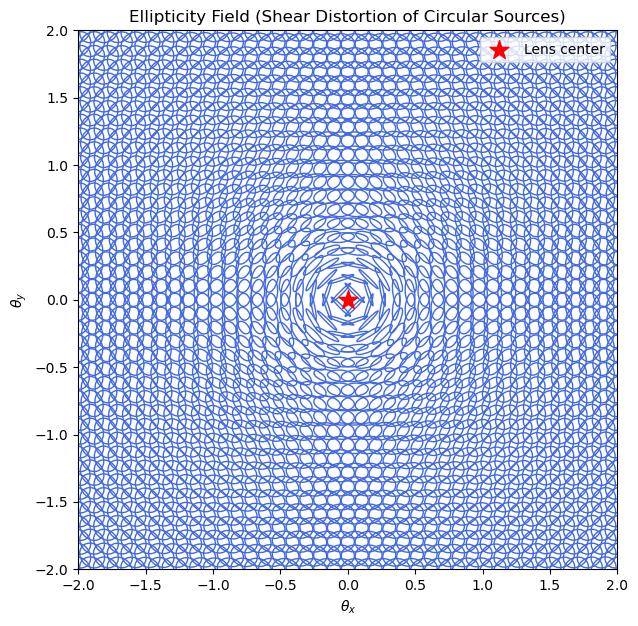

In [8]:
# Grid
theta = np.linspace(-2, 2, 40)
theta_x, theta_y = np.meshgrid(theta, theta)
r = np.sqrt(theta_x**2 + theta_y**2)
phi = np.arctan2(theta_y, theta_x)

# Tangential shear field
theta_E = 0.5
gamma_mag = theta_E / (2 * (r + 0.05))
gamma1 = -gamma_mag * np.cos(2 * phi)
gamma2 = -gamma_mag * np.sin(2 * phi)

# Complex shear
gamma = gamma1 + 1j * gamma2

# Plot and setup
fig, ax = plt.subplots(figsize=(7, 7))
ellipse_size = 0.2

for i in range(theta_x.shape[0]):
    for j in range(theta_x.shape[1]):
        g = gamma[i, j]
        amp = np.abs(g)
        amp = min(amp, 0.8)                 # avoid extreme flattening
        ang = 0.5 * np.angle(g) * 180/np.pi # spin-2 rotation
        q = (1 - amp) / (1 + amp)           # axis ratio from ellipticity

        e = Ellipse(
            (theta_x[i, j], theta_y[i, j]),
            width=ellipse_size,
            height=ellipse_size * q,
            angle=ang,
            edgecolor='royalblue',
            facecolor='none',
            lw=1
        )
        ax.add_patch(e)
ax.scatter(0, 0, color='red', s=200, marker='*', label='Lens center')
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
ax.set_aspect('equal')
ax.set_xlabel(r'$\theta_x$')
ax.set_ylabel(r'$\theta_y$')
ax.set_title("Ellipticity Field (Shear Distortion of Circular Sources)")
ax.legend(loc='upper right')
plt.show()

Lensing Distortion for Given Shear and Convergence
---------------------------------------------------

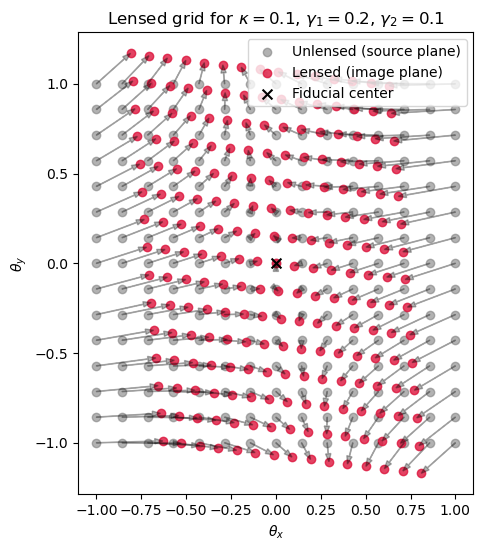

In [9]:
# For a given kappa and gamma(1,2), need to be scalar here
kappa = 0.1
gamma1 = 0.2
gamma2 = 0.1

# Define amplification matrix accordingly
A = calculate_amplification_matrix(gamma1, gamma2, kappa)

# Fiducial grid
x = np.linspace(-1, 1, 15)
y = np.linspace(-1, 1, 15)
theta_x, theta_y = np.meshgrid(x, y)

theta = np.column_stack((theta_x.ravel(), theta_y.ravel()))

# Each point θ maps to β = A · θ
beta = theta @ A.T  # shape (N, 2)

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

# Unlensed grid (gray)
ax.scatter(theta[:,0], theta[:,1], color='gray',
           label='Unlensed (source plane)', alpha=0.6)
# Lensed grid (red)
ax.scatter(beta[:,0], beta[:,1], color='crimson',
           label='Lensed (image plane)', alpha=0.8)
# Fiducial center
ax.scatter(0, 0, color='black', s=50, marker='x',
           label='Fiducial center')

# Arrows showing displacements
for i in range(len(theta)):
    ax.arrow(theta[i,0], theta[i,1],
             beta[i,0]-theta[i,0],
             beta[i,1]-theta[i,1],
             color='k', alpha=0.3, width=0.002, head_width=0.03,
             length_includes_head=True)

ax.set_aspect('equal')
ax.set_xlabel(r'$\theta_x$')
ax.set_ylabel(r'$\theta_y$')
ax.set_title(
    fr"Lensed grid for $\kappa={kappa}$, $\gamma_1={gamma1}$, $\gamma_2={gamma2}$")
ax.legend()
plt.show()

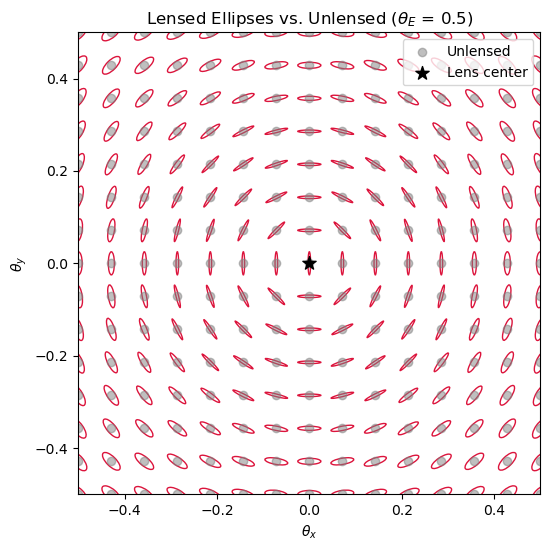

In [13]:
# Parameters
theta_E = 0.5   # Einstein radius (arcsec)
n = 15
extent = 0.5
ellipse_size = 0.05  # base diameter of each ellipse

# Grid
x = np.linspace(-extent, extent, n)
y = np.linspace(-extent, extent, n)
theta_x, theta_y = np.meshgrid(x, y)
R = np.sqrt(theta_x**2 + theta_y**2)
phi = np.arctan2(theta_y, theta_x)
epsilon = 1e-7

# Isothermal distribution
kappa = theta_E / (2 * (R + epsilon))
gamma_mag = kappa
gamma1 = -gamma_mag * np.cos(2 * phi)
gamma2 = -gamma_mag * np.sin(2 * phi)
gamma = gamma1 + 1j*gamma2  # complex shear

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

# Lensed ellipses
for i in range(n):
    for j in range(n):
        g = gamma[j, i]
        amp = np.abs(g)
        amp = min(amp, 0.8)  # cap extreme flattening for visualization
        q = (1 - amp) / (1 + amp)  # axis ratio
        ang = 0.5 * np.angle(g) * 180 / np.pi  # spin-2: half angle

        e = Ellipse(
            (theta_x[j, i], theta_y[j, i]),
            width=ellipse_size,
            height=ellipse_size * q,
            angle=ang,
            edgecolor='crimson',
            facecolor='none',
            lw=1
        )
        ax.add_patch(e)

# Unlensed grid
ax.scatter(theta_x, theta_y, color='gray', alpha=0.5, label='Unlensed')
# Lens center
ax.scatter(0, 0, color='black', s=100, marker='*', label='Lens center')

ax.set_aspect('equal')
ax.set_xlim(-extent, extent)
ax.set_ylim(-extent, extent)
ax.set_xlabel(r'$\theta_x$')
ax.set_ylabel(r'$\theta_y$')
ax.set_title(f"Lensed Ellipses vs. Unlensed ($\\theta_E$ = {theta_E})")
ax.legend(loc='upper right')
plt.show()

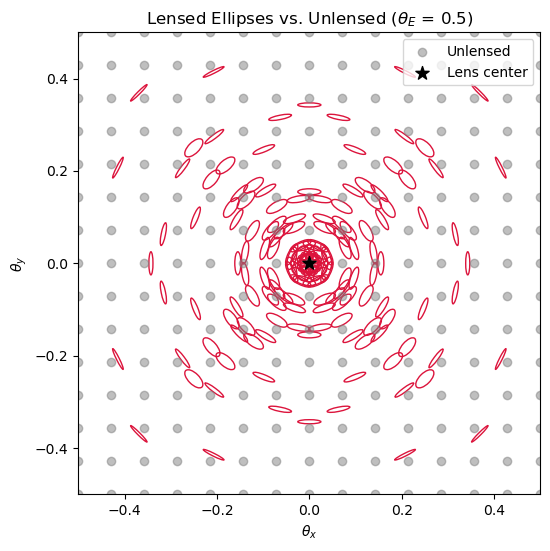

In [21]:
# Parameters
theta_E = 0.5   # Einstein radius (arcsec)
n = 15
extent = 0.5
ellipse_size = 0.05  # base diameter of each ellipse

# Grid
x = np.linspace(-extent, extent, n)
y = np.linspace(-extent, extent, n)
theta_x, theta_y = np.meshgrid(x, y)
R = np.sqrt(theta_x**2 + theta_y**2)
phi = np.arctan2(theta_y, theta_x)
epsilon = 1e-7

# Isothermal distribution
kappa = theta_E / (2 * (R + epsilon))
gamma_mag = kappa
gamma1 = -gamma_mag * np.cos(2 * phi)
gamma2 = -gamma_mag * np.sin(2 * phi)
gamma = gamma1 + 1j*gamma2  # complex shear

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

# Lensed ellipses
for i in range(n):
    for j in range(n):
        g = gamma[j, i]
        amp = np.abs(g)
        amp = min(amp, 0.8)  # cap extreme flattening for visualization
        q = (1 - amp) / (1 + amp)  # axis ratio
        ang = 0.5 * np.angle(g) * 180 / np.pi  # spin-2: half angle
        alpha_x = (theta_E**2/(R[j,i]**2 + epsilon))*theta_x[j, i]
        alpha_y = (theta_E**2/(R[j,i]**2 + epsilon))*theta_y[j, i]

        e = Ellipse(
            (theta_x[j, i] - alpha_x, theta_y[j, i] - alpha_y),
            width=ellipse_size,
            height=ellipse_size * q,
            angle=ang,
            edgecolor='crimson',
            facecolor='none',
            lw=1
        )
        ax.add_patch(e)

# Unlensed grid
ax.scatter(theta_x, theta_y, color='gray', alpha=0.5, label='Unlensed')
# Lens center
ax.scatter(0, 0, color='black', s=100, marker='*', label='Lens center')

ax.set_aspect('equal')
ax.set_xlim(-extent, extent)
ax.set_ylim(-extent, extent)
ax.set_xlabel(r'$\theta_x$')
ax.set_ylabel(r'$\theta_y$')
ax.set_title(f"Lensed Ellipses vs. Unlensed ($\\theta_E$ = {theta_E})")
ax.legend(loc='upper right')
plt.show()

Tangential Shear Pattern Around a Mass Center
=============================================

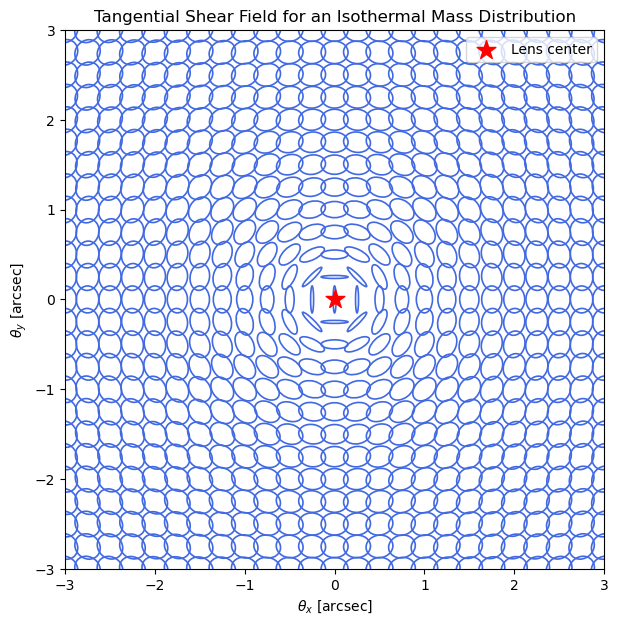

In [19]:
# Parameters
theta_E = 0.5        # Einstein radius (arcsec)
npts = 25            # grid points
extent = 3.0         # field size in arcsec
ellipse_size = 0.3   # base ellipse diameter

# Grid
x = np.linspace(-extent, extent, npts)
y = np.linspace(-extent, extent, npts)
theta_x, theta_y = np.meshgrid(x, y)
r = np.sqrt(theta_x**2 + theta_y**2)
phi = np.arctan2(theta_y, theta_x)
epsilon = 1e-4

# Isothermal distribution
kappa = theta_E / (2 * (r + epsilon))
gamma = kappa * np.exp(2j * phi + np.pi * 1j)  # tangential shear pattern

# Plot
fig, ax = plt.subplots(figsize=(7, 7))

for i in range(npts):
    for j in range(npts):
        g = gamma[j, i]
        amp = np.abs(g)
        amp = min(amp, 0.8)                 # cap the shear
        ang = 0.5 * np.angle(g) * 180/np.pi # spin-2: half the complex angle
        q = (1 - amp) / (1 + amp)           # axis ratio from shear magnitude

        e = Ellipse(
            (theta_x[j, i], theta_y[j, i]),
            width=ellipse_size,
            height=ellipse_size * q,
            angle=ang,
            edgecolor='royalblue',
            facecolor='none',
            lw=1.2
        )
        ax.add_patch(e)
ax.scatter(0, 0, color='red', s=200, marker='*', label='Lens center')
ax.set_aspect('equal')
ax.set_xlim(-extent, extent)
ax.set_ylim(-extent, extent)
ax.set_xlabel(r'$\theta_x$ [arcsec]')
ax.set_ylabel(r'$\theta_y$ [arcsec]')
ax.set_title("Tangential Shear Field for an Isothermal Mass Distribution")
ax.legend(loc='upper right')
plt.show()

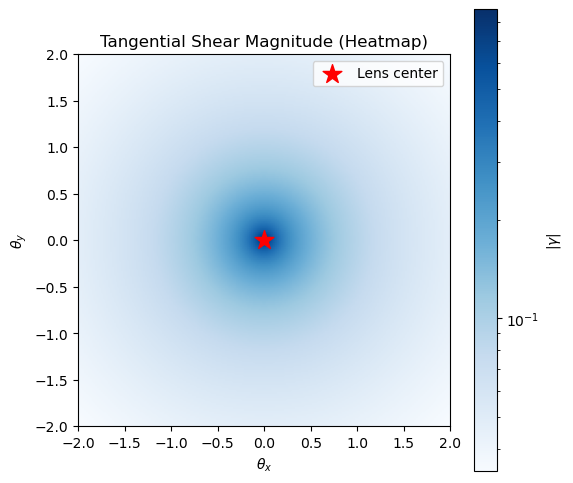

In [20]:
# Heat map style version
theta = np.linspace(-2, 2, 200)
theta_x, theta_y = np.meshgrid(theta, theta)
r = np.sqrt(theta_x**2 + theta_y**2)
phi = np.arctan2(theta_y, theta_x)

gamma_t = 0.1 / (r + 0.1)

gamma1 = -gamma_t * np.cos(2*phi)
gamma2 = -gamma_t * np.sin(2*phi)

gamma_mag = np.sqrt(gamma1**2 + gamma2**2) # shear magnitude

fig, ax = plt.subplots(figsize=(6,6))
im = ax.imshow(
    gamma_mag,
    extent=[theta.min(), theta.max(), theta.min(), theta.max()],
    origin='lower',
    cmap='Blues',
    norm=LogNorm(vmin=gamma_mag.min(), vmax=gamma_mag.max())
)
ax.scatter(0, 0, color='red', marker='*', s=200, label='Lens center')
ax.set_aspect('equal')
ax.set_xlabel(r'$\theta_x$')
ax.set_ylabel(r'$\theta_y$')
ax.set_title("Tangential Shear Magnitude (Heatmap)")
plt.colorbar(im, ax=ax, label=r'$|\gamma|$')
ax.legend()
plt.show()

In [14]:
gamma.shape

(25, 25)